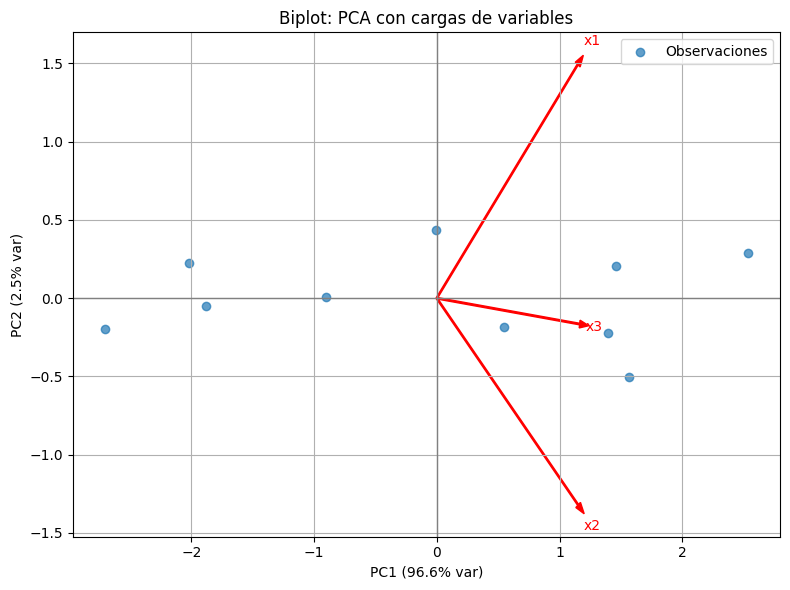

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Datos ficticios
X = np.array([
    [2.5, 2.4, 8.0],
    [0.5, 0.7, 2.5],
    [2.2, 2.9, 7.9],
    [1.9, 2.2, 6.8],
    [3.1, 3.0, 8.7],
    [2.3, 2.7, 7.5],
    [2.0, 1.6, 6.0],
    [1.0, 1.1, 3.1],
    [1.5, 1.6, 4.0],
    [1.1, 0.9, 2.8]
])
feature_names = ['x1', 'x2', 'x3']

# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA (2 componentes)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Obtener componentes (cargas)
components = pca.components_.T  # transpuesta: filas = variables, columnas = PC
explained_var = pca.explained_variance_ratio_

# Crear el biplot
plt.figure(figsize=(8, 6))

# 1. Proyección de los datos
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, label="Observaciones")

# 2. Flechas para las variables originales
for i, var in enumerate(feature_names):
    plt.arrow(0, 0, components[i, 0] * 2, components[i, 1] * 2,
              color='r', width=0.01, head_width=0.05)
    plt.text(components[i, 0] * 2.2, components[i, 1] * 2.2, var, color='r', ha='center', va='center')

# Etiquetas de los ejes
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
plt.title("Biplot: PCA con cargas de variables")
plt.grid(True)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.legend()
plt.tight_layout()
plt.show()
